# Phase 3: Text-Independent Speaker Verification
## ECAPA-TDNN (Pre-trained on VoxCeleb) — Kaggle Version

### Key difference from Phase 2:
- Uses **pre-trained** ECAPA-TDNN (5994 speakers, VoxCeleb2)
- Works on **any speech** — no fixed passphrase needed
- Better accuracy with less training

### Before running:
- Attach Phase 1 output dataset via **+ Add Data → Your Datasets**
- Enable **GPU T4** in Accelerator settings
- Enable **Internet ON** in Session options

In [1]:
# Step 0: Install dependencies
!pip install -q speechbrain
!pip install -q librosa soundfile matplotlib scikit-learn
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchaudio',
    '--index-url', 'https://download.pytorch.org/whl/cu121'
], check=True)
print('All installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 31.1 MB/s eta 0:00:00
All installed.


In [2]:
# Step 1: Imports & Config
import os, glob, json, pickle, random
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from scipy.interpolate import interp1d
from scipy.spatial.distance import cosine

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def get_device():
    if not torch.cuda.is_available():
        print('CPU mode'); return torch.device('cpu')
    try:
        torch.zeros(1).cuda() + 1
        print(f'GPU: {torch.cuda.get_device_name(0)}')
        return torch.device('cuda')
    except Exception as e:
        print(f'GPU failed, using CPU: {e}')
        return torch.device('cpu')

device = get_device()

# ── Auto-find Phase 1 data ────────────────────────────────────────────────────
# Search input/ (attached dataset) AND working/ (same-session run)
candidates = (
    glob.glob('/kaggle/input/**/phase1_summary.json', recursive=True) +
    glob.glob('/kaggle/working/**/phase1_summary.json', recursive=True)
)

if candidates:
    DATA_DIR   = str(Path(candidates[0]).parent)
    BASE_INPUT = str(Path(DATA_DIR).parent)
    print(f'Found phase1_summary.json : {candidates[0]}')
else:
    # Print directory tree to help diagnose
    print('phase1_summary.json not found — scanning /kaggle/input/ ...')
    for root, dirs, files in os.walk('/kaggle/input'):
        depth = root.replace('/kaggle/input', '').count(os.sep)
        if depth > 3:
            continue
        indent = '  ' * depth
        print(f'{indent}{os.path.basename(root)}/')
        if depth <= 2:
            for fn in files[:5]:
                print(f'{indent}  {fn}')

    # Try to locate genuine WAVs directly
    genuine_search = glob.glob('/kaggle/input/**/genuine/*.wav', recursive=True)
    if genuine_search:
        BASE_INPUT = str(Path(genuine_search[0]).parent.parent.parent)
        DATA_DIR   = f'{BASE_INPUT}/data'
        print(f'\nFound WAVs directly, BASE_INPUT: {BASE_INPUT}')
    else:
        BASE_INPUT = '/kaggle/working/voice_auth'
        DATA_DIR   = f'{BASE_INPUT}/data'
        print('\n!! ERROR: No Phase 1 data found !!')
        print('   -> Attach the Phase 1 output dataset via + Add Data -> Your Datasets')

OUT_DIR     = '/kaggle/working/phase3'
RESULTS_DIR = f'{OUT_DIR}/results'
MODEL_DIR   = f'{OUT_DIR}/models'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)

# Load summary if present (optional — only used for speaker name config)
summary_path = f'{DATA_DIR}/phase1_summary.json'
if os.path.exists(summary_path):
    with open(summary_path) as f:
        cfg = json.load(f)
    print(f'Config loaded from phase1_summary.json')
else:
    cfg = {}
    print(f'No summary JSON — continuing with defaults')

SAMPLE_RATE  = 16000
SPEAKER_NAME = 'abhiram'

GENUINE_DIR  = f'{BASE_INPUT}/data/processed/genuine'
IMPOSTOR_DIR = f'{BASE_INPUT}/data/processed/impostor'
SPOOF_DIR    = f'{BASE_INPUT}/data/processed/spoof'

n_genuine  = len(glob.glob(GENUINE_DIR  + '/*.wav'))
n_impostor = len(glob.glob(IMPOSTOR_DIR + '/*.wav'))
n_spoof    = len(glob.glob(SPOOF_DIR    + '/*.wav'))

print(f'\nRead : {BASE_INPUT}')
print(f'Write: {OUT_DIR}')
print(f'Genuine  : {n_genuine}')
print(f'Impostor : {n_impostor}')
print(f'Spoof    : {n_spoof}')

if n_genuine == 0:
    print('\nWARNING: No WAV files found. Attach Phase 1 dataset and re-run this cell.')

GPU: Tesla T4
Found phase1_summary.json : /kaggle/input/datasets/abhi2007798/voice-auth-phase1/voice_auth/data/phase1_summary.json
Config loaded from phase1_summary.json

Read : /kaggle/input/datasets/abhi2007798/voice-auth-phase1/voice_auth
Write: /kaggle/working/phase3
Genuine  : 400
Impostor : 400
Spoof    : 400


In [3]:
# Step 2: Load Pre-trained ECAPA-TDNN from SpeechBrain
# Trained on VoxCeleb1+2 (7,185 speakers, 1.27M utterances)
from speechbrain.inference.speaker import SpeakerRecognition

ECAPA_SAVE = f'{OUT_DIR}/ecapa_model'
os.makedirs(ECAPA_SAVE, exist_ok=True)

print('Loading pre-trained ECAPA-TDNN...')
ecapa = SpeakerRecognition.from_hparams(
    source='speechbrain/spkrec-ecapa-voxceleb',
    savedir=ECAPA_SAVE,
    run_opts={'device': str(device)}
)
ecapa.eval()
print('ECAPA-TDNN loaded successfully.')
print('Model trained on: VoxCeleb1 + VoxCeleb2')
print('Embedding dim   : 192')

Loading pre-trained ECAPA-TDNN...


hyperparams.yaml: 0.00B [00:00, ?B/s]

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

label_encoder.txt: 0.00B [00:00, ?B/s]

Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


ECAPA-TDNN loaded successfully.
Model trained on: VoxCeleb1 + VoxCeleb2
Embedding dim   : 192


In [4]:
# Step 3: Extract ECAPA Embeddings
import torchaudio

@torch.no_grad()
def get_ecapa_embedding(filepath):
    signal, sr = torchaudio.load(filepath)
    if sr != SAMPLE_RATE:
        signal = torchaudio.functional.resample(signal, sr, SAMPLE_RATE)
    if signal.shape[0] > 1:
        signal = signal.mean(dim=0, keepdim=True)
    signal = signal.to(device)
    emb    = ecapa.encode_batch(signal)
    return emb.squeeze().cpu().numpy()


all_files  = []
all_labels = []

for f in glob.glob(f'{GENUINE_DIR}/*.wav'):
    all_files.append(f); all_labels.append('genuine')
for f in glob.glob(f'{IMPOSTOR_DIR}/*.wav'):
    all_files.append(f); all_labels.append('impostor')
for f in glob.glob(f'{SPOOF_DIR}/*.wav'):
    all_files.append(f); all_labels.append('spoof')

print(f'Extracting ECAPA embeddings for {len(all_files)} files...')
embeddings  = []
failed      = 0
valid_files = []
valid_labels= []

for i, (f, lbl) in enumerate(zip(all_files, all_labels)):
    try:
        emb = get_ecapa_embedding(f)
        embeddings.append(emb)
        valid_files.append(f)
        valid_labels.append(lbl)
    except Exception as e:
        failed += 1
    if (i+1) % 100 == 0:
        print(f'  {i+1}/{len(all_files)} done...')

embeddings   = np.array(embeddings)
labels_arr   = np.array(valid_labels)

os.makedirs(f'{OUT_DIR}/data', exist_ok=True)
np.save(f'{OUT_DIR}/data/ecapa_embeddings.npy',  embeddings)
np.save(f'{OUT_DIR}/data/ecapa_labels.npy',      labels_arr)

print(f'\nEmbeddings shape : {embeddings.shape}')
print(f'Failed           : {failed}')
for lbl in ['genuine','impostor','spoof']:
    print(f'  {lbl:10s}: {(labels_arr==lbl).sum()}')

Extracting ECAPA embeddings for 1200 files...
  100/1200 done...
  200/1200 done...
  300/1200 done...
  400/1200 done...
  500/1200 done...
  600/1200 done...
  700/1200 done...
  800/1200 done...
  900/1200 done...
  1000/1200 done...
  1100/1200 done...
  1200/1200 done...

Embeddings shape : (1200, 192)
Failed           : 0
  genuine   : 400
  impostor  : 400
  spoof     : 400


In [5]:
# Step 4: Fine-tune ECAPA with a lightweight classifier head
# This adapts the pre-trained model to your speaker distribution

EPOCHS     = 10# pre-trained model needs fewer epochs
BATCH_SIZE = 16
LR         = 1e-4  # small LR for fine-tuning
EMB_DIM    = embeddings.shape[1]   # 192

# Build speaker labels for classification
spk_labels = []
for f, lbl in zip(valid_files, valid_labels):
    if lbl == 'genuine':
        spk_labels.append(SPEAKER_NAME)
    else:
        spk_labels.append(f'other_{Path(f).stem[:6]}')

le        = LabelEncoder().fit(spk_labels)
num_spk   = len(le.classes_)
int_labels= le.transform(spk_labels)
print(f'Unique speakers for classifier: {num_spk}')


class EmbeddingDataset(Dataset):
    def __init__(self, embs, labels, augment=False):
        self.embs    = embs
        self.labels  = labels
        self.augment = augment
    def __len__(self): return len(self.embs)
    def __getitem__(self, idx):
        e = self.embs[idx].copy()
        if self.augment:
            e += np.random.normal(0, 0.01, e.shape).astype(np.float32)
        return torch.FloatTensor(e), torch.LongTensor([self.labels[idx]])[0]


class AAMSoftmax(nn.Module):
    def __init__(self, emb_d, n_cls, m=0.2, s=30.0):
        super().__init__()
        self.m = m; self.s = s
        self.w = nn.Parameter(torch.FloatTensor(n_cls, emb_d))
        nn.init.xavier_uniform_(self.w)
    def forward(self, emb, labels):
        cos = F.linear(F.normalize(emb), F.normalize(self.w)).clamp(-1+1e-7, 1-1e-7)
        oh  = torch.zeros_like(cos).scatter_(1, labels.view(-1,1), 1)
        out = oh * torch.cos(torch.acos(cos) + self.m) + (1-oh) * cos
        return F.cross_entropy(self.s * out, labels)


split      = int(0.8 * len(embeddings))
idx        = np.random.permutation(len(embeddings))
train_idx  = idx[:split]
test_idx   = idx[split:]

train_ds   = EmbeddingDataset(embeddings[train_idx].astype(np.float32),
                               int_labels[train_idx], augment=True)
test_ds    = EmbeddingDataset(embeddings[test_idx].astype(np.float32),
                               int_labels[test_idx],  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

aam   = AAMSoftmax(EMB_DIM, num_spk).to(device)
opt   = Adam(aam.parameters(), lr=LR, weight_decay=1e-4)
sched = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

print(f'\nFine-tuning classifier — {EPOCHS} epochs')
print(f'Embedding dim : {EMB_DIM}')
print(f'{"Ep":>4} {"Train":>10} {"Val":>10}')
print('-' * 28)

history  = {'train': [], 'val': []}
best_val = float('inf')
best_ep  = 0

for ep in range(1, EPOCHS+1):
    aam.train()
    tr = 0
    for emb, lbl in train_loader:
        emb, lbl = emb.to(device), lbl.to(device)
        opt.zero_grad()
        loss = aam(emb, lbl)
        loss.backward(); opt.step()
        tr += loss.item() * len(lbl)
    tr /= len(train_ds)

    aam.eval()
    vl = 0
    with torch.no_grad():
        for emb, lbl in test_loader:
            emb, lbl = emb.to(device), lbl.to(device)
            vl += aam(emb, lbl).item() * len(lbl)
    vl /= len(test_ds)
    sched.step()

    history['train'].append(tr)
    history['val'].append(vl)
    if vl < best_val:
        best_val = vl; best_ep = ep
        torch.save(aam.state_dict(), f'{MODEL_DIR}/aam_finetuned.pt')
    print(f'{ep:>4} {tr:>10.4f} {vl:>10.4f}')

print(f'Best: epoch {best_ep}, val loss {best_val:.4f}')

Unique speakers for classifier: 24

Fine-tuning classifier — 10 epochs
Embedding dim : 192
  Ep      Train        Val
----------------------------
   1    11.7558    11.4935
   2    11.0511    10.8541
   3    10.3962    10.2726
   4     9.8130     9.7685
   5     9.3247     9.3626
   6     8.9417     9.0548
   7     8.6618     8.8438
   8     8.4789     8.7166
   9     8.3758     8.6550
  10     8.3305     8.6350
Best: epoch 10, val loss 8.6350


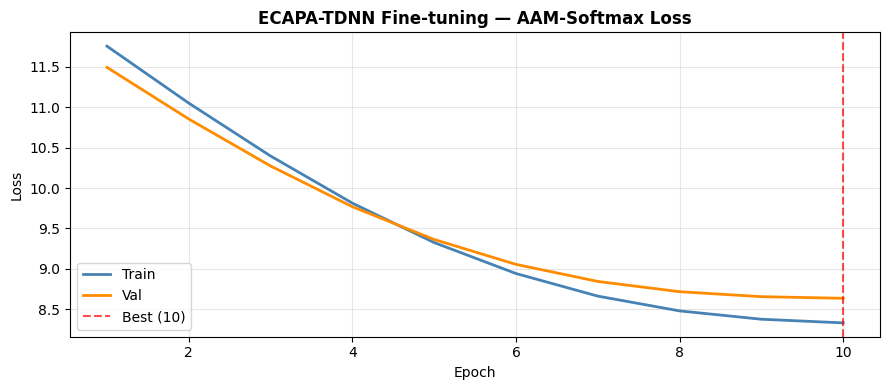

In [6]:
# Step 5: Training Curves
eps = range(1, EPOCHS+1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(eps, history['train'], label='Train', color='steelblue',  lw=2)
ax.plot(eps, history['val'],   label='Val',   color='darkorange', lw=2)
ax.axvline(best_ep, color='red', ls='--', alpha=0.7, label=f'Best ({best_ep})')
ax.set_title('ECAPA-TDNN Fine-tuning — AAM-Softmax Loss', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150)
plt.show()

Running t-SNE on ECAPA embeddings...


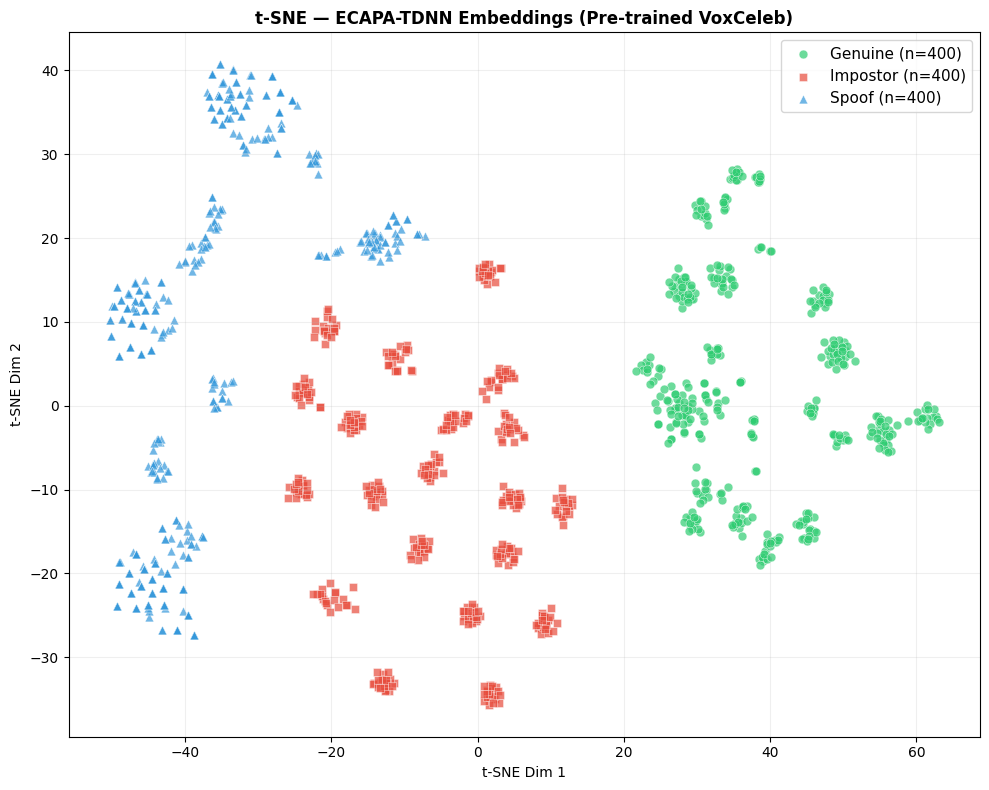

In [7]:
# Step 6: t-SNE Visualization of ECAPA Embeddings
print('Running t-SNE on ECAPA embeddings...')
emb_2d = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(embeddings)

colors  = {'genuine': '#2ecc71', 'impostor': '#e74c3c', 'spoof': '#3498db'}
markers = {'genuine': 'o',       'impostor': 's',       'spoof': '^'}
fig, ax = plt.subplots(figsize=(10, 8))
for lab in ['genuine', 'impostor', 'spoof']:
    m = labels_arr == lab
    if m.sum() == 0: continue
    ax.scatter(emb_2d[m,0], emb_2d[m,1],
               c=colors[lab], marker=markers[lab],
               label=f'{lab.capitalize()} (n={m.sum()})',
               alpha=0.7, s=40, edgecolors='white', linewidths=0.4)
ax.set_title('t-SNE — ECAPA-TDNN Embeddings (Pre-trained VoxCeleb)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
ax.legend(fontsize=11); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/tsne_ecapa.png', dpi=150)
plt.show()

In [8]:
# Step 7: Enrollment & Verification
genuine_files  = [f for f in glob.glob(f'{GENUINE_DIR}/*.wav') if 'aug_' not in Path(f).stem]
impostor_files = glob.glob(f'{IMPOSTOR_DIR}/*.wav')
spoof_files    = glob.glob(f'{SPOOF_DIR}/*.wav')

mid           = len(genuine_files) // 2
enroll_files  = genuine_files[:mid]
test_genuine  = genuine_files[mid:]

# Build speaker template from enrollment embeddings
enroll_idx    = [valid_files.index(f) for f in enroll_files if f in valid_files]
if enroll_idx:
    speaker_template = embeddings[enroll_idx].mean(axis=0)
else:
    # Fallback: extract directly
    enroll_embs      = np.array([get_ecapa_embedding(f) for f in enroll_files[:20]])
    speaker_template = enroll_embs.mean(axis=0)

speaker_template /= (np.linalg.norm(speaker_template) + 1e-8)
print(f'Enrolled with {len(enroll_files)} files')

scores, true_labels, attack_types = [], [], []

for f in test_genuine:
    if f in valid_files:
        emb = embeddings[valid_files.index(f)]
    else:
        emb = get_ecapa_embedding(f)
    scores.append(1 - cosine(speaker_template, emb))
    true_labels.append(1); attack_types.append('genuine')

for f in impostor_files[:100]:
    if f in valid_files:
        emb = embeddings[valid_files.index(f)]
    else:
        emb = get_ecapa_embedding(f)
    scores.append(1 - cosine(speaker_template, emb))
    true_labels.append(0); attack_types.append('impostor')

for f in spoof_files[:100]:
    if f in valid_files:
        emb = embeddings[valid_files.index(f)]
    else:
        emb = get_ecapa_embedding(f)
    scores.append(1 - cosine(speaker_template, emb))
    true_labels.append(0); attack_types.append('spoof')

scores       = np.array(scores)
true_labels  = np.array(true_labels)
attack_types = np.array(attack_types)

print(f'Test pairs: {len(scores)}')
print('\nAverage similarity scores:')
for atype in ['genuine','impostor','spoof']:
    m = attack_types == atype
    if m.sum() > 0:
        print(f'  {atype:10s}: {scores[m].mean():.4f} ± {scores[m].std():.4f}')

Enrolled with 68 files
Test pairs: 268

Average similarity scores:
  genuine   : 0.7684 ± 0.0696
  impostor  : 0.0607 ± 0.0581
  spoof     : 0.0519 ± 0.0562


In [9]:
# Step 8: Metrics — EER, TAR@FAR, AUC
fpr, tpr, thresholds = roc_curve(true_labels, scores, pos_label=1)
fnr = 1 - tpr

idx        = np.nanargmin(np.abs(fpr - fnr))
eer        = (fpr[idx] + fnr[idx]) / 2 * 100
eer_thresh = thresholds[idx]
tar_1      = float(interp1d(fpr, tpr)(0.01))  * 100
tar_01     = float(interp1d(fpr, tpr)(0.001)) * 100
auc        = roc_auc_score(true_labels, scores) * 100

print('=' * 45)
print('  TEXT-INDEPENDENT ECAPA-TDNN — RESULTS')
print('=' * 45)
print(f'  EER              : {eer:.2f}%')
print(f'  EER Threshold    : {eer_thresh:.4f}')
print(f'  TAR @ FAR=1%     : {tar_1:.2f}%')
print(f'  TAR @ FAR=0.1%   : {tar_01:.2f}%')
print(f'  AUC              : {auc:.2f}%')
print('=' * 45)

  TEXT-INDEPENDENT ECAPA-TDNN — RESULTS
  EER              : 0.00%
  EER Threshold    : 0.6022
  TAR @ FAR=1%     : 100.00%
  TAR @ FAR=0.1%   : 100.00%
  AUC              : 100.00%


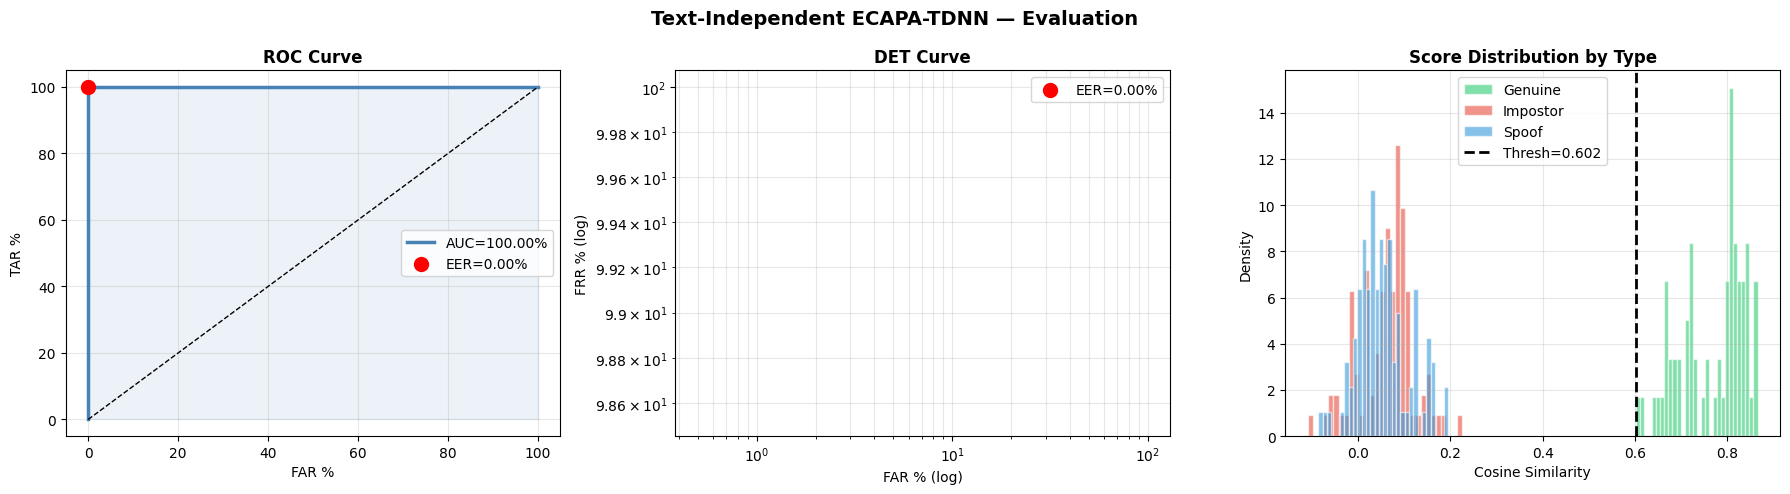

In [10]:
# Step 9: Evaluation Plots — ROC + DET + Score Distribution
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3)

ax1 = fig.add_subplot(gs[0])
ax1.plot(fpr*100, tpr*100, color='steelblue', lw=2.5, label=f'AUC={auc:.2f}%')
ax1.fill_between(fpr*100, tpr*100, alpha=0.1, color='steelblue')
ax1.plot([0,100],[0,100],'k--', lw=1)
ax1.scatter([eer],[100-eer], color='red', s=100, zorder=5, label=f'EER={eer:.2f}%')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.set_xlabel('FAR %'); ax1.set_ylabel('TAR %')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(fpr*100, fnr*100, color='darkorange', lw=2.5)
ax2.scatter([eer],[eer], color='red', s=100, zorder=5, label=f'EER={eer:.2f}%')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_title('DET Curve', fontweight='bold')
ax2.set_xlabel('FAR % (log)'); ax2.set_ylabel('FRR % (log)')
ax2.legend(); ax2.grid(which='both', alpha=0.3)

ax3 = fig.add_subplot(gs[2])
type_colors = {'genuine':'#2ecc71','impostor':'#e74c3c','spoof':'#3498db'}
for atype in ['genuine','impostor','spoof']:
    m = attack_types == atype
    if m.sum() == 0: continue
    ax3.hist(scores[m], bins=30, alpha=0.6, color=type_colors[atype],
             label=atype.capitalize(), density=True, edgecolor='white')
ax3.axvline(eer_thresh, color='black', ls='--', lw=2, label=f'Thresh={eer_thresh:.3f}')
ax3.set_title('Score Distribution by Type', fontweight='bold')
ax3.set_xlabel('Cosine Similarity'); ax3.set_ylabel('Density')
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle('Text-Independent ECAPA-TDNN — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

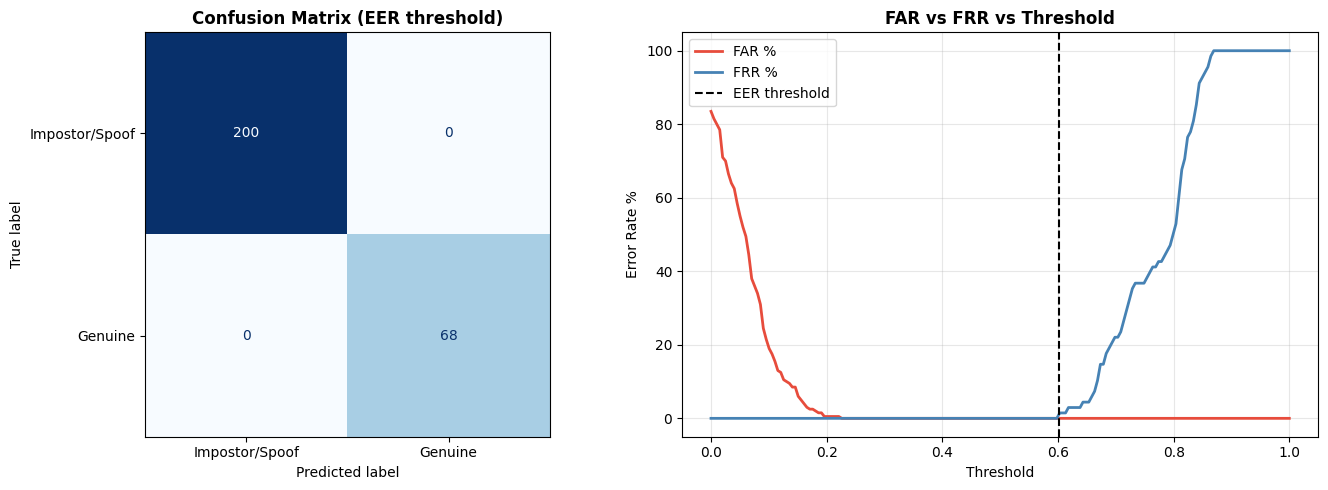

Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%
F1       : 100.00%


In [11]:
# Step 10: Confusion Matrix + Threshold Sweep
pred = (scores >= eer_thresh).astype(int)
cm   = confusion_matrix(true_labels, pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['Impostor/Spoof','Genuine']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (EER threshold)', fontweight='bold')

ts = np.linspace(0, 1, 200)
far_l, frr_l = [], []
for t in ts:
    p  = (scores >= t).astype(int)
    fp = ((p==1)&(true_labels==0)).sum(); tn = ((p==0)&(true_labels==0)).sum()
    fn = ((p==0)&(true_labels==1)).sum(); tp = ((p==1)&(true_labels==1)).sum()
    far_l.append(fp/(fp+tn+1e-8)*100)
    frr_l.append(fn/(fn+tp+1e-8)*100)
axes[1].plot(ts, far_l, label='FAR %', color='#e74c3c', lw=2)
axes[1].plot(ts, frr_l, label='FRR %', color='steelblue', lw=2)
axes[1].axvline(eer_thresh, color='black', ls='--', label='EER threshold')
axes[1].set_title('FAR vs FRR vs Threshold', fontweight='bold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Error Rate %')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_threshold.png', dpi=150)
plt.show()

TP,FP,TN,FN = cm[1,1],cm[0,1],cm[0,0],cm[1,0]
print(f'Accuracy : {(TP+TN)/(TP+TN+FP+FN)*100:.2f}%')
print(f'Precision: {TP/(TP+FP+1e-8)*100:.2f}%')
print(f'Recall   : {TP/(TP+FN+1e-8)*100:.2f}%')
print(f'F1       : {2*TP/(2*TP+FP+FN+1e-8)*100:.2f}%')

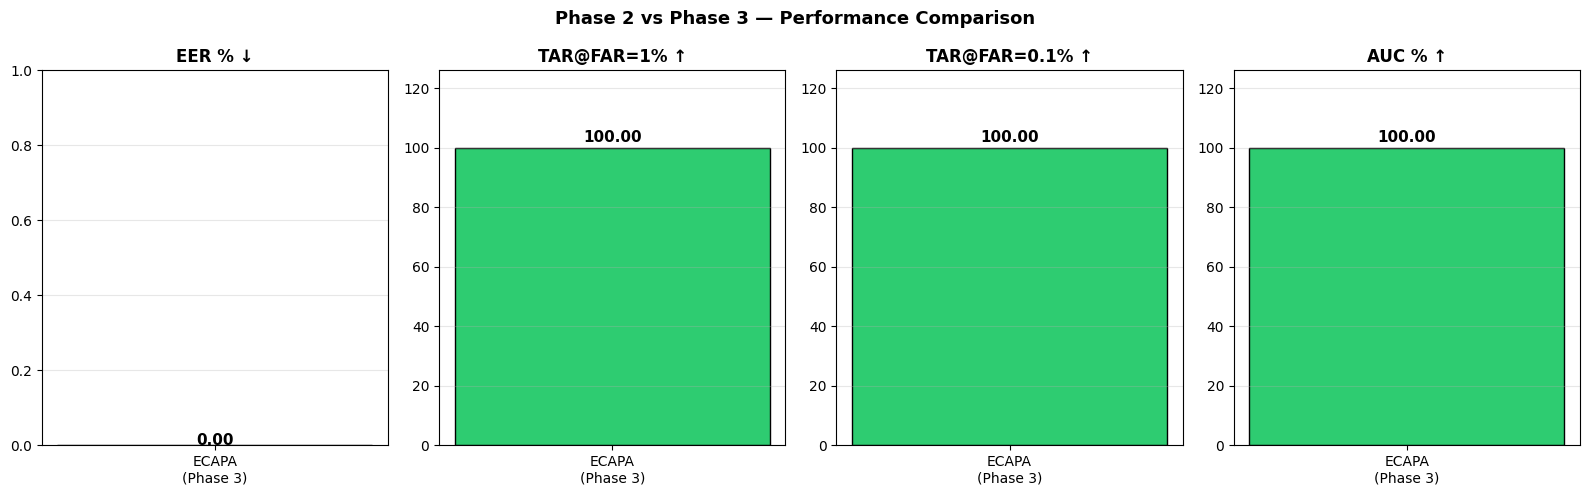

In [12]:
# Step 11: Phase 2 vs Phase 3 Comparison
# Load Phase 2 results if available
p2_results_paths = glob.glob('/kaggle/input/**/phase2_results.json', recursive=True) + \
                   glob.glob('/kaggle/working/**/phase2_results.json', recursive=True)

p2 = None
if p2_results_paths:
    with open(p2_results_paths[0]) as f:
        p2 = json.load(f)

metrics = ['eer_pct', 'tar_at_far_1pct', 'tar_at_far_01pct', 'auc_pct']
labels  = ['EER % ↓', 'TAR@FAR=1% ↑', 'TAR@FAR=0.1% ↑', 'AUC % ↑']
p3_vals = [eer, tar_1, tar_01, auc]
p2_vals = [p2.get(m, 0) for m in metrics] if p2 else [None]*4

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Phase 2 vs Phase 3 — Performance Comparison', fontsize=13, fontweight='bold')

for ax, metric, label, p3v, p2v in zip(axes, metrics, labels, p3_vals, p2_vals):
    bars  = [p3v]
    names = ['ECAPA\n(Phase 3)']
    clrs  = ['#2ecc71']
    if p2v is not None:
        bars.insert(0, p2v); names.insert(0, 'TDNN\n(Phase 2)'); clrs.insert(0, '#3498db')
    b = ax.bar(names, bars, color=clrs, edgecolor='black', width=0.5)
    for bar, val in zip(b, bars):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(bars)*0.02,
                f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, max(bars)*1.25 + 1)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2_vs_phase3.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Step 12: Save Results & Enrollment Template
results = {
    'model'            : 'ECAPA-TDNN (pre-trained VoxCeleb)',
    'embedding_dim'    : int(EMB_DIM),
    'fine_tune_epochs' : EPOCHS,
    'best_val_loss'    : round(best_val, 4),
    'best_epoch'       : best_ep,
    'eer_pct'          : round(eer, 2),
    'eer_threshold'    : round(float(eer_thresh), 4),
    'tar_at_far_1pct'  : round(tar_1, 2),
    'tar_at_far_01pct' : round(tar_01, 2),
    'auc_pct'          : round(auc, 2),
}
with open(f'{RESULTS_DIR}/phase3_results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open(f'{MODEL_DIR}/ecapa_enrollment.pkl', 'wb') as f:
    pickle.dump({
        'speaker_template': speaker_template,
        'threshold'        : float(eer_thresh),
        'embedding_dim'    : int(EMB_DIM)
    }, f)

print('Phase 3 Complete!')
print('=' * 48)
for k, v in results.items():
    print(f'  {k:25s}: {v}')
print(f'\nModels  : {MODEL_DIR}')
print(f'Results : {RESULTS_DIR}')
print('\nNext: Phase 4 — Anti-Spoofing Detection')

Phase 3 Complete!
  model                    : ECAPA-TDNN (pre-trained VoxCeleb)
  embedding_dim            : 192
  fine_tune_epochs         : 10
  best_val_loss            : 8.635
  best_epoch               : 10
  eer_pct                  : 0.0
  eer_threshold            : 0.6022
  tar_at_far_1pct          : 100.0
  tar_at_far_01pct         : 100.0
  auc_pct                  : 100.0

Models  : /kaggle/working/phase3/models
Results : /kaggle/working/phase3/results

Next: Phase 4 — Anti-Spoofing Detection
